# Training KIND model on filtered TESLA data

The data is supposed to be filtered into stationary- and transient-like data snippets. The data is used to train the full version of KIND model.

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import util_data
import ex_detuning

### KIND training

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/kalman',
        '--file_name', 'detuning_meas',
        '--data_nsample', '144',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
    ]
)


In [3]:
model = kind.model(args)

dataset = ex_detuning.dataset_filtered(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample)
)

### Training the mean of a stationary operator

In [4]:
model.train()
model.fit(dataset)

>>> train nominal mean >>>
	epoch 1 losses: train=1.841554, valid=1.771436, test=1.766517
	validation loss decreased (inf -> 1.771436), saving model ...
	epoch 2 losses: train=1.372949, valid=0.980751, test=0.968873
	validation loss decreased (1.771436 -> 0.980751), saving model ...
	epoch 3 losses: train=0.915818, valid=0.924103, test=0.908276
	validation loss decreased (0.980751 -> 0.924103), saving model ...
	epoch 4 losses: train=0.897902, valid=0.906749, test=0.894348
	validation loss decreased (0.924103 -> 0.906749), saving model ...
	epoch 5 losses: train=0.890864, valid=0.903224, test=0.885199
	validation loss decreased (0.906749 -> 0.903224), saving model ...
	epoch 6 losses: train=0.837539, valid=0.766236, test=0.758529
	validation loss decreased (0.903224 -> 0.766236), saving model ...
	epoch 7 losses: train=0.740859, valid=0.729176, test=0.724069
	validation loss decreased (0.766236 -> 0.729176), saving model ...
	epoch 8 losses: train=0.711134, valid=0.705631, test=0.70166

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

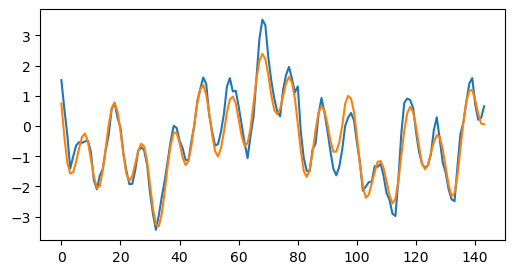

In [6]:
jdata = 9

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

### Training the uncertainty of a stationary operator

In [7]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train nominal uncertainty >>>
	epoch 1 losses: train=0.910959, valid=0.958120, test=0.966549
	validation loss decreased (inf -> 0.958120), saving model ...
	epoch 2 losses: train=0.930767, valid=0.980481, test=0.983471
	early stopping counter: 1 out of 30
	epoch 3 losses: train=0.778122, valid=0.703606, test=0.700305
	validation loss decreased (0.958120 -> 0.703606), saving model ...
	epoch 4 losses: train=0.649281, valid=0.604420, test=0.597827
	validation loss decreased (0.703606 -> 0.604420), saving model ...
	epoch 5 losses: train=0.595475, valid=0.599631, test=0.588431
	validation loss decreased (0.604420 -> 0.599631), saving model ...
	epoch 6 losses: train=0.564017, valid=0.578142, test=0.572602
	validation loss decreased (0.599631 -> 0.578142), saving model ...
	epoch 7 losses: train=0.567696, valid=0.624384, test=0.624483
	early stopping counter: 1 out of 30
	epoch 8 losses: train=1.746249, valid=1.145890, test=1.537930
	early stopping counter: 2 out of 30
	epoch 9 losses:

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

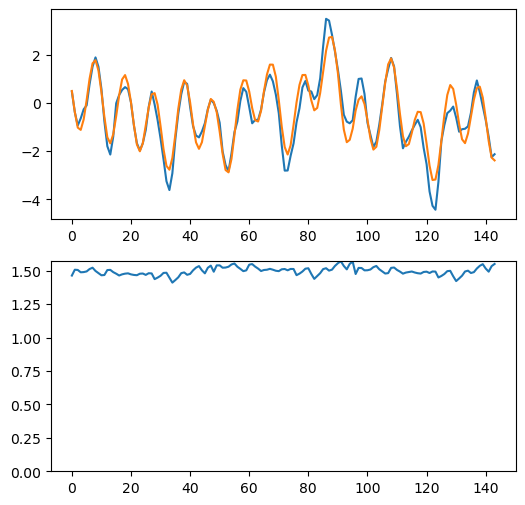

In [9]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

### Training the mean of a transient operator

In [10]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train excursion mean >>>
	epoch 1 losses: train=1.980730, valid=1.908591, test=2.178115
	validation loss decreased (inf -> 1.908591), saving model ...
	epoch 2 losses: train=1.865880, valid=1.612455, test=1.849427
	validation loss decreased (1.908591 -> 1.612455), saving model ...
	epoch 3 losses: train=1.526078, valid=1.271604, test=1.405501
	validation loss decreased (1.612455 -> 1.271604), saving model ...
	epoch 4 losses: train=1.242552, valid=1.183046, test=1.316119
	validation loss decreased (1.271604 -> 1.183046), saving model ...
	epoch 5 losses: train=1.194977, valid=1.082068, test=1.179816
	validation loss decreased (1.183046 -> 1.082068), saving model ...
	epoch 6 losses: train=0.931689, valid=0.933277, test=0.974499
	validation loss decreased (1.082068 -> 0.933277), saving model ...
	epoch 7 losses: train=0.761707, valid=0.668315, test=0.690708
	validation loss decreased (0.933277 -> 0.668315), saving model ...
	epoch 8 losses: train=0.672437, valid=0.637637, test=0.668

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

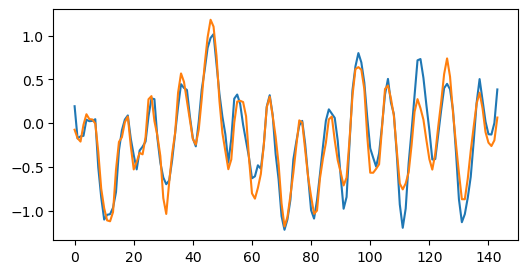

In [12]:
jdata = 21

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

### Training the uncertainty of a transient operator

In [13]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train excursion uncertainty >>>
	epoch 1 losses: train=0.231038, valid=0.254254, test=0.248875
	validation loss decreased (inf -> 0.254254), saving model ...
	epoch 2 losses: train=0.221683, valid=0.254035, test=0.248744
	validation loss decreased (0.254254 -> 0.254035), saving model ...
	epoch 3 losses: train=0.220268, valid=0.254028, test=0.248726
	validation loss decreased (0.254035 -> 0.254028), saving model ...
	epoch 4 losses: train=0.218868, valid=0.254815, test=0.249326
	early stopping counter: 1 out of 30
	epoch 5 losses: train=0.219155, valid=0.254090, test=0.248736
	early stopping counter: 2 out of 30
	epoch 6 losses: train=0.219416, valid=0.256127, test=0.251132
	early stopping counter: 3 out of 30
	epoch 7 losses: train=0.219491, valid=0.255037, test=0.249521
	early stopping counter: 4 out of 30
	epoch 8 losses: train=0.219951, valid=0.254539, test=0.249105
	early stopping counter: 5 out of 30
	epoch 9 losses: train=0.219792, valid=0.254372, test=0.248954
	early stoppi

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

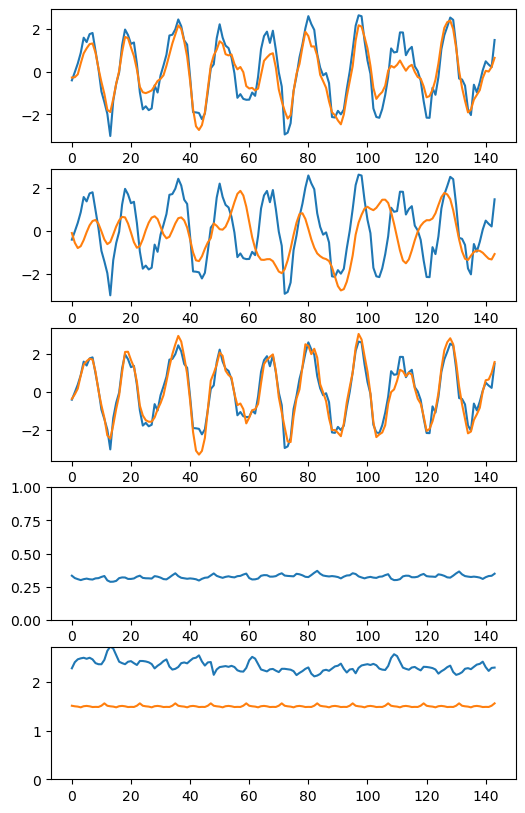

In [29]:
jdata = 13

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break